# Basic Graph — LangGraph Fundamentals

This notebook introduces the **core building blocks** of LangGraph: the structural pieces you use to wire any agent or workflow.

By the end you will understand:

1. **State** — the shared data passed between nodes
2. **Nodes** — units of work (plain Python functions)
3. **Edges** — how control flows between nodes
4. **Conditional edges** — branching based on state
5. **Compiling and running** a graph

> LangGraph models computation as a **directed graph**. Each node reads from a shared state object and returns an update to it. Edges decide what runs next.

## 1. Setup

Install LangGraph if it is not already available in your environment.

In [1]:
# %pip install -q langgraph

In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

/opt/homebrew/lib/python3.11/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


## 2. Define the State

Every LangGraph graph is built around a **state schema**. The schema describes the shape of the data that flows through the graph.

The simplest way to define state is a `TypedDict`. Each node receives the current state and returns a partial dict of fields to update.

In [3]:
class GraphState(TypedDict):
    text: str
    word_count: int
    classification: str

## 3. Define Nodes

A **node** is just a Python function with signature `state -> dict`. The returned dict is **merged** into the state.

We will create three nodes:

- `normalize` — clean up the input text
- `count_words` — compute the word count
- `classify_short` / `classify_long` — assign a label based on length

In [4]:
def normalize(state: GraphState) -> dict:
    cleaned = state["text"].strip().lower()
    print(f"[normalize] -> {cleaned!r}")
    return {"text": cleaned}

def count_words(state: GraphState) -> dict:
    n = len(state["text"].split())
    print(f"[count_words] -> {n}")
    return {"word_count": n}

def classify_short(state: GraphState) -> dict:
    print("[classify_short]")
    return {"classification": "short"}

def classify_long(state: GraphState) -> dict:
    print("[classify_long]")
    return {"classification": "long"}

## 4. Build the Graph

We use a `StateGraph` and add our nodes. Then we wire them together with edges.

- `START` is the special entry marker.
- `END` is the special terminal marker.
- `add_edge(a, b)` means "after node `a` runs, run node `b`".

In [5]:
builder = StateGraph(GraphState)

builder.add_node("normalize", normalize)
builder.add_node("count_words", count_words)
builder.add_node("classify_short", classify_short)
builder.add_node("classify_long", classify_long)

builder.add_edge(START, "normalize")
builder.add_edge("normalize", "count_words")

## 5. Conditional Edges

A **conditional edge** picks the next node based on the current state. You provide a router function that returns a string key, and a mapping from those keys to node names.

In [6]:
def route_by_length(state: GraphState) -> str:
    return "long" if state["word_count"] > 5 else "short"

builder.add_conditional_edges(
    "count_words",
    route_by_length,
    {"short": "classify_short", "long": "classify_long"},
)

builder.add_edge("classify_short", END)
builder.add_edge("classify_long", END)

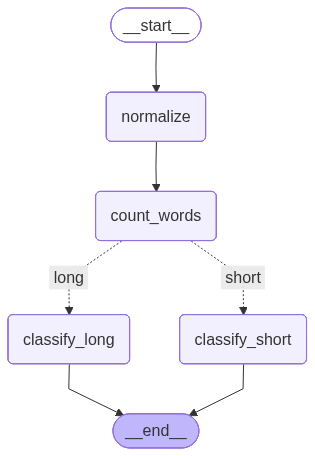

In [7]:
from IPython.display import Image, display

preview = builder.compile()
display(Image(preview.get_graph().draw_mermaid_png()))

## 6. Compile and Visualize

Calling `.compile()` validates the graph and returns a runnable. LangGraph can also render the structure as a Mermaid diagram.

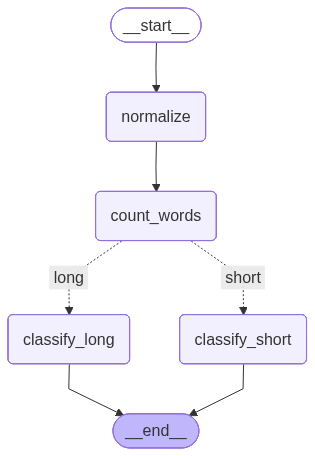

In [8]:
graph = builder.compile()

try:
    from IPython.display import Image, display
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("(Skipping diagram — requires network/mermaid:", e, ")")
    print(graph.get_graph().draw_mermaid())

## 7. Run the Graph

Invoke the compiled graph with an initial state. The result is the final merged state.

In [9]:
result = graph.invoke({"text": "  Hello LangGraph  "})
print("\nFinal state:", result)

[normalize] -> 'hello langgraph'
[count_words] -> 2
[classify_short]

Final state: {'text': 'hello langgraph', 'word_count': 2, 'classification': 'short'}


In [10]:
result = graph.invoke({"text": "LangGraph makes building agentic workflows much easier than from scratch"})
print("\nFinal state:", result)

[normalize] -> 'langgraph makes building agentic workflows much easier than from scratch'
[count_words] -> 10
[classify_long]

Final state: {'text': 'langgraph makes building agentic workflows much easier than from scratch', 'word_count': 10, 'classification': 'long'}


## 8. Streaming Intermediate Steps

Use `.stream()` to observe each node's update as the graph executes. This is invaluable for debugging more complex graphs.

In [11]:
for step in graph.stream({"text": "a short one"}):
    print(step)

[normalize] -> 'a short one'
{'normalize': {'text': 'a short one'}}
[count_words] -> 3
{'count_words': {'word_count': 3}}
[classify_short]
{'classify_short': {'classification': 'short'}}


## Recap

| Concept | API |
|---|---|
| Define shared data | `TypedDict` passed to `StateGraph(...)` |
| Add a unit of work | `builder.add_node(name, fn)` |
| Sequential flow | `builder.add_edge(a, b)` |
| Branching | `builder.add_conditional_edges(src, router, mapping)` |
| Entry / exit | `START`, `END` |
| Run | `graph.compile().invoke(state)` |
| Trace | `graph.stream(state)` |

### Next steps
- Add an LLM call inside a node.
- Use `Annotated[list, add]` reducers to **append** to lists instead of overwriting.
- Explore cycles (loops) for ReAct-style agents — see `Hands_on_Introduction_to_LangGraph.ipynb`.